In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [4]:
df=pd.read_csv("Loan_default_noisy.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,Master's,Full-time,Married,No,No,Other,NaN,0
2,C1OZ6DPJ8Y,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
print(f"Information :\n{df.info()}\nDescribe :\n{df.describe().T}\nShape :\n{df.shape}\nColumns :\n{df.columns}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255847 entries, 0 to 255846
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255847 non-null  object 
 1   Age             250644 non-null  float64
 2   Income          250787 non-null  float64
 3   LoanAmount      250768 non-null  float64
 4   CreditScore     250741 non-null  float64
 5   MonthsEmployed  250672 non-null  float64
 6   NumCreditLines  250718 non-null  object 
 7   InterestRate    250802 non-null  float64
 8   LoanTerm        250772 non-null  float64
 9   DTIRatio        250841 non-null  float64
 10  Education       250613 non-null  object 
 11  EmploymentType  250710 non-null  object 
 12  MaritalStatus   250630 non-null  object 
 13  HasMortgage     250631 non-null  object 
 14  HasDependents   250660 non-null  object 
 15  LoanPurpose     250675 non-null  object 
 16  HasCoSigner     250773 non-null  object 
 17  Default   

In [6]:
print(f"NAN Values :\n{df.isna().sum()}\nDuplicate Values :{df.duplicated().sum()}")

NAN Values :
LoanID               0
Age               5203
Income            5060
LoanAmount        5079
CreditScore       5106
MonthsEmployed    5175
NumCreditLines    5129
InterestRate      5045
LoanTerm          5075
DTIRatio          5006
Education         5234
EmploymentType    5137
MaritalStatus     5217
HasMortgage       5216
HasDependents     5187
LoanPurpose       5172
HasCoSigner       5074
Default              0
dtype: int64
Duplicate Values :494


In [7]:
df["NumCreditLines"].value_counts()
# df['NumCreditLines'] = pd.to_numeric(df['NumCreditLines'], errors='coerce')
df["NumCreditLines"].replace("Unknown",np.nan,inplace=True)
df["NumCreditLines"].value_counts()

,count
NumCreditLines,
2.0,62640
3.0,62387
4.0,62374
1.0,62074


In [8]:
df.info()
df["NumCreditLines"]=df["NumCreditLines"].astype("float64")
df["NumCreditLines"].dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255847 entries, 0 to 255846
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255847 non-null  object 
 1   Age             250644 non-null  float64
 2   Income          250787 non-null  float64
 3   LoanAmount      250768 non-null  float64
 4   CreditScore     250741 non-null  float64
 5   MonthsEmployed  250672 non-null  float64
 6   NumCreditLines  249475 non-null  object 
 7   InterestRate    250802 non-null  float64
 8   LoanTerm        250772 non-null  float64
 9   DTIRatio        250841 non-null  float64
 10  Education       250613 non-null  object 
 11  EmploymentType  250710 non-null  object 
 12  MaritalStatus   250630 non-null  object 
 13  HasMortgage     250631 non-null  object 
 14  HasDependents   250660 non-null  object 
 15  LoanPurpose     250675 non-null  object 
 16  HasCoSigner     250773 non-null  object 
 17  Default   

dtype('float64')

In [9]:

df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

In [10]:
print(df['Education'].value_counts())
print(df['Education'].unique())


df['Education'] = df['Education'].replace({'Bachelors': "Bachelor's", 'phd': 'PhD'})
print(df['Education'].unique())

Education
High School    62579
Master's       62321
Bachelor's     56679
PhD            55984
Bachelors       6309
phd             6253
Name: count, dtype: int64
["Bachelor's" "Master's" 'High School' 'PhD' 'Bachelors' 'phd' nan]
["Bachelor's" "Master's" 'High School' 'PhD' nan]


In [11]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Income'] >= Q1 - 1.5 * IQR) & (df['Income'] <= Q3 + 1.5 * IQR)]
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[(df['CreditScore'] >= 300) & (df['CreditScore'] <= 850)]

In [ ]:
# Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
#        'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
#        'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
#        'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
#        'Default']
for i in df.columns:
  if df[i].dtype=="object" or i=="NumCreditLines":
    df[i].fillna(df[i].mode()[0],inplace=True)
  else:
    if i == 'Default':
      continue
    else:
      df[i].fillna(df[i].median(),inplace=True)
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [12]:
df=df.dropna()

In [13]:
numeric_columns=['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio'
 ]
categorical_columns=["Education","EmploymentType","MaritalStatus","HasMortgage","HasDependents","LoanPurpose","HasCoSigner"]

In [ ]:
# for i in categorical_columns:
#     print(i)
#     print(df[i].value_counts().sort_values(ascending=False))
#     plt.figure(figsize=(6,4))
#     plt.title(i)
#     sns.countplot(x=df[i],hue=df["Default"])
#     plt.show()

In [ ]:
# for i in numeric_columns:
#     plt.figure(figsize=(10,5))
#     plt.title(i)
#     sns.histplot(x=df[i],kde=True,hue=df["Default"])
#     plt.show()

In [ ]:
# sns.pairplot(df,hue="Default")

In [ ]:
# for i in numeric_columns:
#   for j in categorical_columns:
#     sns.barplot(x=df[j],y=df[i],hue=df["Default"])
    # plt.show()

In [ ]:
# for i in numeric_columns:
#   for j in categorical_columns:
#     sns.boxplot(y=df[j],x=df[i],hue=df["Default"])
    # plt.show()

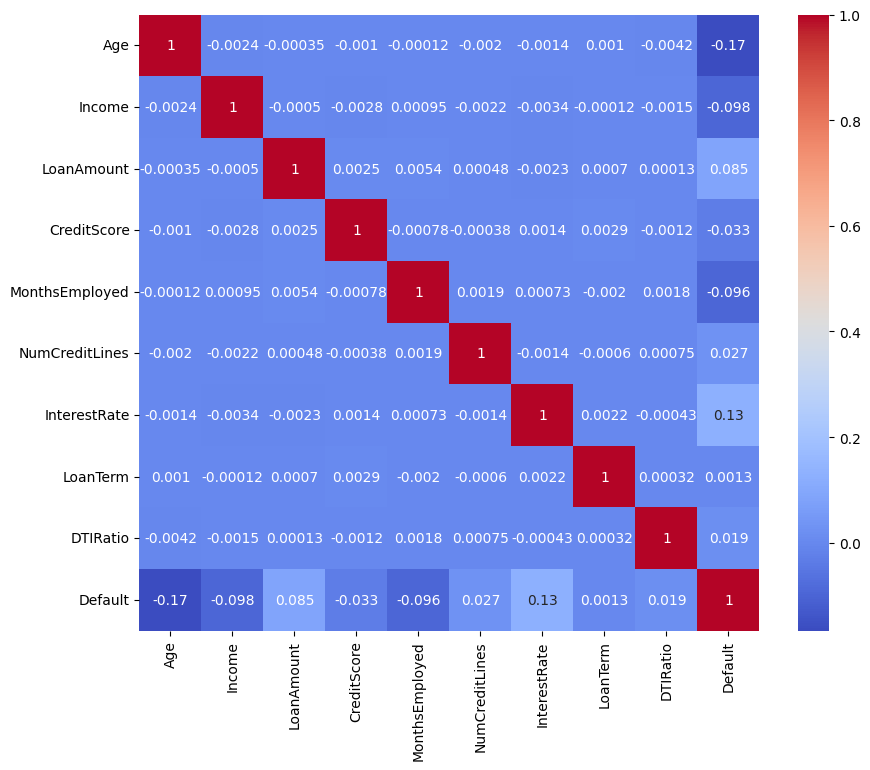

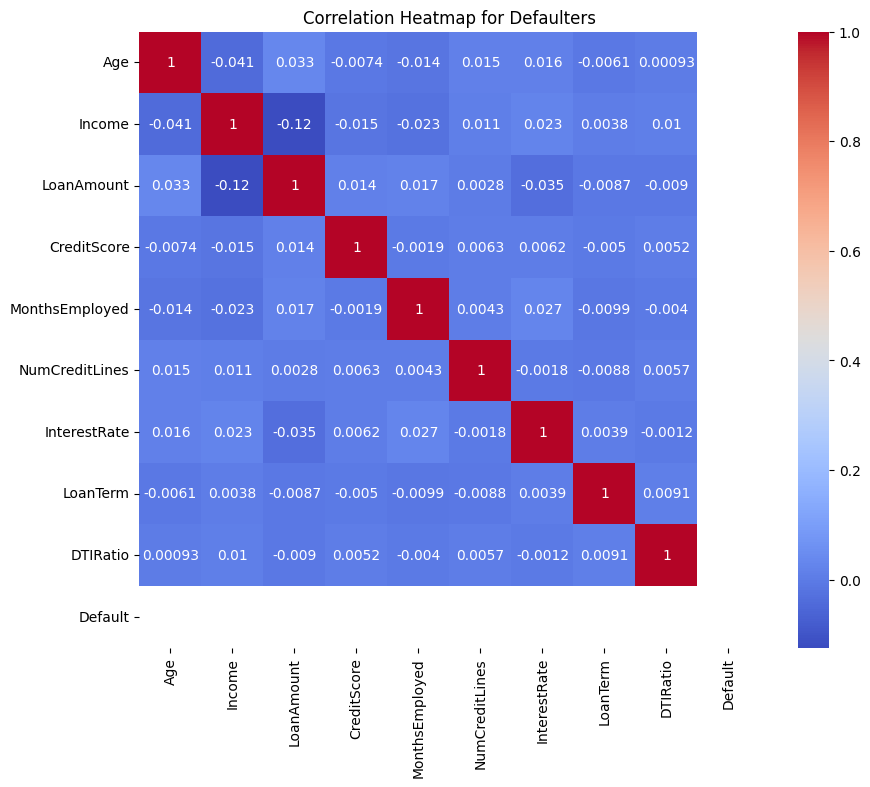

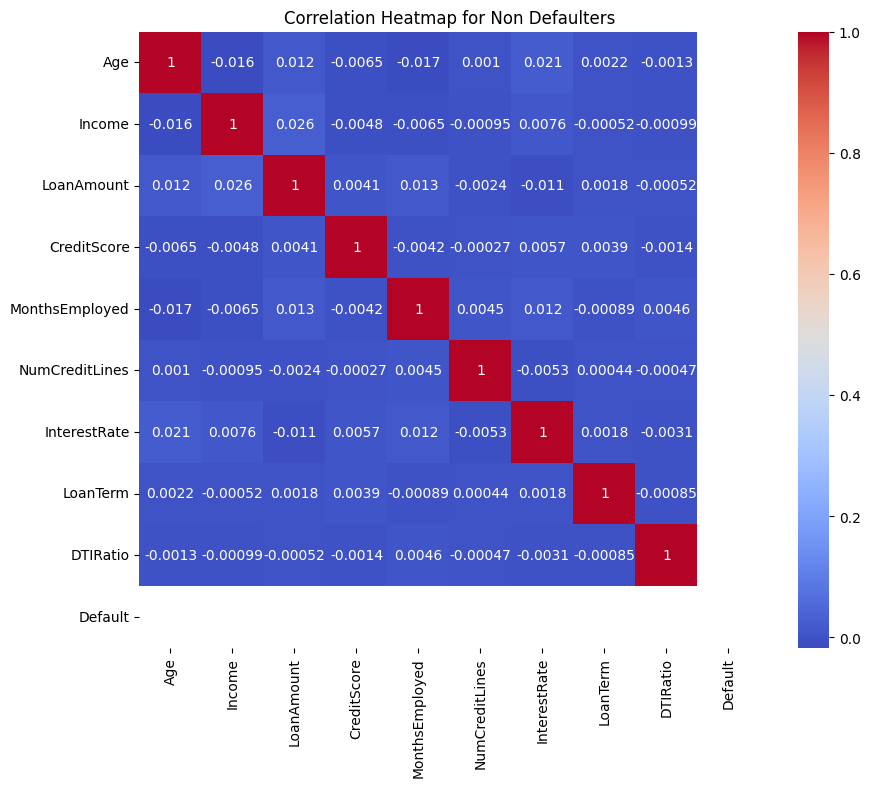

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

df1=pd.DataFrame(df[df["Default"]==1])
df0=pd.DataFrame(df[df["Default"]==0])


plt.figure(figsize=(10,8))
plt.title("Correlation Heatmap for Defaulters")
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

plt.figure(figsize=(10,8))
plt.title("Correlation Heatmap for Non Defaulters")
sns.heatmap(df0.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [15]:
print(df["MaritalStatus"].unique(),
df["EmploymentType"].unique())

['Divorced' 'Married' 'Single'] ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']


In [16]:
df=pd.get_dummies(df,columns=["Education","EmploymentType","MaritalStatus","LoanPurpose"],drop_first=True)

In [17]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,I38PQUQS96,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,...,False,False,False,False,False,False,False,False,False,True
2,C1OZ6DPJ8Y,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,...,False,False,False,True,False,False,False,False,False,False
3,V2KKSFM3UN,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,...,False,False,False,False,True,False,True,False,False,False
4,EY08JDHTZP,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,...,False,False,False,True,False,False,False,False,False,False
5,A9S62RQ7US,25.0,90298.0,90448.0,720.0,18.0,2.0,22.72,24.0,0.10,...,False,False,False,True,False,True,True,False,False,False


In [18]:
df.drop("LoanID",axis=1,inplace=True)

In [19]:
# df=df.astype("int")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183574 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           183574 non-null  float64
 1   Income                        183574 non-null  float64
 2   LoanAmount                    183574 non-null  float64
 3   CreditScore                   183574 non-null  float64
 4   MonthsEmployed                183574 non-null  float64
 5   NumCreditLines                183574 non-null  float64
 6   InterestRate                  183574 non-null  float64
 7   LoanTerm                      183574 non-null  float64
 8   DTIRatio                      183574 non-null  float64
 9   HasMortgage                   183574 non-null  object 
 10  HasDependents                 183574 non-null  object 
 11  HasCoSigner                   183574 non-null  object 
 12  Default                       183574 non-null  in

In [20]:
print([df[i].unique() for i in ["HasMortgage","HasDependents","HasCoSigner"]])

[array(['Yes', 'No'], dtype=object), array(['Yes', 'No'], dtype=object), array(['Yes', 'No'], dtype=object)]


In [21]:
df[["HasMortgage", "HasDependents", "HasCoSigner"]] = df[["HasMortgage", "HasDependents", "HasCoSigner"]].replace({'Yes': 1, 'No': 0})


In [22]:
df=df.astype("float64")

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255379,25.0,96657.0,45630.0,466.0,14.0,2.0,21.13,36.0,0.70,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
255465,65.0,108866.0,169844.0,468.0,43.0,2.0,19.85,12.0,0.82,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
255611,21.0,109816.0,107955.0,754.0,100.0,2.0,22.65,48.0,0.34,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
255799,61.0,72111.0,162188.0,623.0,23.0,2.0,20.16,12.0,0.52,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
df["Loan_to_Income_Ratio"]=df['LoanAmount'] / df['Income']

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
# from sklearn.svm import SupportMachineClassifier
from sklearn.neighbors import KNeighborsClassifier


In [50]:
y=df["Default"]
x_ns=df.drop("Default",axis=1)

In [51]:
y.value_counts()

,count
Default,
0.0,162269
1.0,21305


In [52]:
x_train,x_test,y_train,y_test=train_test_split(x_ns,y,test_size=0.1,random_state=42)

In [53]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [54]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
print(f"Before SMOTE: {y_train.value_counts()}")
x_train_scaled, y_train = sm.fit_resample(x_train_scaled, y_train)
print(f"After SMOTE: {y_train.value_counts()}")

Before SMOTE: Default
0.0    146070
1.0     19146
Name: count, dtype: int64
After SMOTE: Default
1.0    146070
0.0    146070
Name: count, dtype: int64


In [55]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [56]:
model_lr=LogisticRegression(class_weight='balanced')
model_lr.fit(x_train_pca,y_train)

LogisticRegression(class_weight='balanced')

In [59]:
y_pred=model_lr.predict(x_test_pca)
print(f1_score(y_test,y_pred,average='weighted'))

print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

0.7421153559202379
accracy score : 0.687983440461924
confusion matrix : 
[[11153  5046]
 [  682  1477]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.94      0.69      0.80     16199
         1.0       0.23      0.68      0.34      2159

    accuracy                           0.69     18358
   macro avg       0.58      0.69      0.57     18358
weighted avg       0.86      0.69      0.74     18358



In [ ]:
# model_lr=LogisticRegression(class_weight={0:1,1:8})
# model_lr=LogisticRegression(class_weight="balanced")
# model_lr.fit(x_train_scaled,y_train)

In [ ]:
# y_pred=model_lr.predict(x_test_scaled)
# print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

In [60]:
# model_knn=KNeighborsClassifier(n_neighbors=5,weights='distance')
model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train_pca,y_train)

KNeighborsClassifier()

In [61]:
y_pred=model_knn.predict(x_test_pca)
print(f"f1 Score :{f1_score(y_test,y_pred,average='weighted')}")

print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

f1 Score :0.7277073869809259
accracy score : 0.6732759559864909
confusion matrix : 
[[11338  4861]
 [ 1137  1022]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.91      0.70      0.79     16199
         1.0       0.17      0.47      0.25      2159

    accuracy                           0.67     18358
   macro avg       0.54      0.59      0.52     18358
weighted avg       0.82      0.67      0.73     18358



In [ ]:
# from sklearn.naive_bayes import GaussianNB
# model_nb=GaussianNB(priors=[0.5, 0.5])
# model_nb.fit(x_train_scaled,y_train)

In [ ]:
# y_pred=model_nb.predict(x_test_scaled)
# print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

In [ ]:
# from sklearn.naive_bayes import ComplementNB
# model_cnb=ComplementNB()
# model_cnb.fit(x_train,y_train)

In [ ]:
# y_pred=model_cnb.predict(x_test)
# print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

In [ ]:
# from sklearn.metrics import precision_recall_curve
# y_scores = model_cnb.predict_proba(x_test_scaled)[:, 1]

# precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# plt.plot(recall, precision, color='blue', label='PR Curve')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.show()

In [63]:
from sklearn.tree import DecisionTreeClassifier
model_dt=DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=20)
model_dt.fit(x_train_pca,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20)

In [65]:
y_pred=model_dt.predict(x_test_pca)
print(f"f1 Score :{f1_score(y_test,y_pred,average='weighted')}")
print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

f1 Score :0.7358924388801645
accracy score : 0.6806296982242074
confusion matrix : 
[[11113  5086]
 [  777  1382]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.93      0.69      0.79     16199
         1.0       0.21      0.64      0.32      2159

    accuracy                           0.68     18358
   macro avg       0.57      0.66      0.56     18358
weighted avg       0.85      0.68      0.74     18358



In [67]:
# feat_importances = pd.Series(model_dt.feature_importances_, index=x_train.columns)
# feat_importances.nlargest(10).sort_values().plot(kind='barh')

# plt.title("Top 10 Decision Tree Feature Importances")
# plt.xlabel("Importance Score")
# plt.show()

In [68]:
df["Age"].unique()

array([56., 46., 32., 60., 25., 38., 40., 28., 41., 53., 20., 39., 19.,
       47., 55., 50., 61., 66., 33., 68., 26., 21., 42., 31., 67., 37.,
       45., 64., 24., 52., 34., 57., 23., 35., 43., 51., 27., 48., 65.,
       62., 58., 18., 59., 29., 54., 44., 30., 49., 69., 36., 22., 63.])

In [69]:
from sklearn.svm import LinearSVC

model_fast_svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
model_fast_svm.fit(x_train_pca, y_train)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

In [70]:
y_pred=model_fast_svm.predict(x_test_pca)
print(f"f1 Score :{f1_score(y_test,y_pred,average='weighted')}")
print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

f1 Score :0.7401439888730468
accracy score : 0.6854232487199041
confusion matrix : 
[[11100  5099]
 [  676  1483]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.94      0.69      0.79     16199
         1.0       0.23      0.69      0.34      2159

    accuracy                           0.69     18358
   macro avg       0.58      0.69      0.57     18358
weighted avg       0.86      0.69      0.74     18358



In [75]:
from sklearn.svm import SVC
# model_svm=SVC(kernel="linear")
model_svm=SVC(kernel="rbf",class_weight='balanced')
model_svm.fit(x_train_pca[:30000],y_train[:30000])

SVC(class_weight='balanced')

In [76]:
y_pred=model_svm.predict(x_test_pca)

print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")
print(f"F1 Score :{f1_score(y_test,y_pred,average='weighted')}")

accracy score : 0.7151105784943894
confusion matrix : 
[[11847  4352]
 [  878  1281]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.93      0.73      0.82     16199
         1.0       0.23      0.59      0.33      2159

    accuracy                           0.72     18358
   macro avg       0.58      0.66      0.57     18358
weighted avg       0.85      0.72      0.76     18358

F1 Score :0.7615096667868678


In [ ]:
# from sklearn.model_selection import cross_val_score


In [ ]:

# scores=cross_val_score(model_svm,x_train_scaled,y_train,cv=5)
# print(scores)

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,Loan_to_Income_Ratio
0,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.588262
1,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.467481
2,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.534154
3,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.412638
4,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.447179


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import StackingClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report
# import seaborn as sns

In [ ]:
# base_learner=[
#     ("dt",DecisionTreeClassifier(class_weight='balanced',max_depth=10,min_samples_leaf=20,random_state=42)),
#     ("svc",SVC(probability=True,kernel="rbf",random_state=42 )),
#     ("lr",LogisticRegression(class_weight="balance",random_state=42))
# ]
# meta_learner=KNeighborsClassifier(n_neighbors=5,weights='distance')


In [ ]:
# stacking_classifier=StackingClassifier(estimators=base_learner,final_estimator=meta_learner,cv=5)

In [ ]:
# stacking_classifier.fit(x_train_scaled,y_train)

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,Loan_to_Income_Ratio
0,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.588262
1,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.467481
2,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.534154
3,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.412638
4,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.447179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255379,25.0,96657.0,45630.0,466.0,14.0,2.0,21.13,36.0,0.70,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.472082
255465,65.0,108866.0,169844.0,468.0,43.0,2.0,19.85,12.0,0.82,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.560120
255611,21.0,109816.0,107955.0,754.0,100.0,2.0,22.65,48.0,0.34,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.983053
255799,61.0,72111.0,162188.0,623.0,23.0,2.0,20.16,12.0,0.52,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.249144


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)


model_rf.fit(x_train_pca, y_train)


y_pred = model_rf.predict(x_test_pca)

In [78]:
y_pred=model_rf.predict(x_test_pca)

print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")
print(f"F1 Score :{f1_score(y_test,y_pred,average='weighted')}")

accracy score : 0.7013291208192614
confusion matrix : 
[[11481  4718]
 [  765  1394]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     16199
         1.0       0.23      0.65      0.34      2159

    accuracy                           0.70     18358
   macro avg       0.58      0.68      0.57     18358
weighted avg       0.85      0.70      0.75     18358

F1 Score :0.751948609811171


In [91]:

y_probs = model_rf.predict_proba(x_test_pca)[:, 1]

#
y_pred_custom = (y_probs >= 0.47).astype(int)

print(f"Final Accuracy: {accuracy_score(y_test, y_pred_custom):.4}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred_custom)}")
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_custom))

Final Accuracy: 0.6652
confusion matrix : 
[[10720  5479]
 [  667  1492]]

Final Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.66      0.78     16199
         1.0       0.21      0.69      0.33      2159

    accuracy                           0.67     18358
   macro avg       0.58      0.68      0.55     18358
weighted avg       0.86      0.67      0.72     18358



In [92]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


scale_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)


xgb_model.fit(x_train_pca, y_train)

y_pred = xgb_model.predict(x_test_pca)


print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")
print(f"F1 Score :{f1_score(y_test,y_pred,average='weighted')}")

accracy score : 0.7301448959581653
confusion matrix : 
[[12166  4033]
 [  921  1238]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83     16199
         1.0       0.23      0.57      0.33      2159

    accuracy                           0.73     18358
   macro avg       0.58      0.66      0.58     18358
weighted avg       0.85      0.73      0.77     18358

F1 Score :0.7723205707256994


In [ ]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier


# base_models = [
#     ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)),
#     ('xgb', XGBClassifier(scale_pos_weight=7.7, learning_rate=0.1, max_depth=6, random_state=42))
# ]


# meta_learner = LogisticRegression(class_weight='balanced')

# stack_model = StackingClassifier(
#     estimators=base_models,
#     final_estimator=meta_learner,
#     cv=5,
#     stack_method='predict_proba'
# )

# stack_model.fit(x_train_scaled, y_train)
# y_pred_stack = stack_model.predict(x_test_scaled)

In [ ]:
# print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")

In [94]:
from sklearn.ensemble import VotingClassifier


voting_clf = VotingClassifier(
    estimators=[
        ('lr', model_lr),    # High Recall
        ('rf', model_rf),    # Stability
        ('xgb', xgb_model)   # High F1-Score
    ],
    # final_estimator=LogisticRegression(class_weight='balanced'),
    voting='soft'
)

voting_clf.fit(x_train_pca, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced')),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     max_depth=12, n_jobs=-1,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [95]:
y_pred = voting_clf.predict(x_test_pca)


print(f"accracy score : {accuracy_score(y_test,y_pred)}\nconfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nclassification report : \n{classification_report(y_test,y_pred)}")
print(f"F1 Score :{f1_score(y_test,y_pred,average='weighted')}")

accracy score : 0.7136943022115699
confusion matrix : 
[[11703  4496]
 [  760  1399]]
classification report : 
              precision    recall  f1-score   support

         0.0       0.94      0.72      0.82     16199
         1.0       0.24      0.65      0.35      2159

    accuracy                           0.71     18358
   macro avg       0.59      0.69      0.58     18358
weighted avg       0.86      0.71      0.76     18358

F1 Score :0.7614389387602919


In [96]:
import joblib

loan_prediction_system = {
    'scaler': ss,
    'pca': pca,
    'model': voting_clf
}


joblib.dump(loan_prediction_system, 'final_loan_default_model.pkl')

print("System finalized and stored as 'final_loan_default_model.pkl'")

System finalized and stored as 'final_loan_default_model.pkl'


In [99]:
import joblib
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
import joblib

def predict_loan_default(input_df, model_path='final_loan_default_model.pkl'):
    system = joblib.load(model_path)
    scaler = system['scaler']
    pca = system['pca']
    model = system['model']

    expected_features = scaler.feature_names_in_

    df_encoded = pd.get_dummies(input_df)


    for col in expected_features:
        if col not in df_encoded.columns:
            df_encoded[col] = 0


    df_encoded = df_encoded[expected_features]


    scaled_data = scaler.transform(df_encoded)


    pca_data = pca.transform(scaled_data)


    prediction = model.predict(pca_data)
    probability = model.predict_proba(pca_data)[:, 1]

    status = "High Risk (Default)" if prediction[0] == 1 else "Low Risk (Non-Default)"
    confidence = round(probability[0] * 100, 2)

    return {
        "Result": status,
        "Probability": f"{confidence}%"
    }


def get_user_input():
    print("\nPlease enter the following customer details:")

    age = int(input("Age: "))
    income = float(input("Annual Income: "))
    loan_amount = float(input("Loan Amount: "))
    credit_score = int(input("Credit Score (300-850): "))
    months_in_job = int(input("Months in current job: "))
    interest_rate = float(input("Interest Rate (e.g., 5.5): "))
    num_credit_lines = int(input("Number of Credit Lines: "))
    loan_term = int(input("Loan Term (Months): "))
    dti_ratio = float(input("Debt-to-Income Ratio (0.0 to 1.0): "))


    print("\nCategorical Options:")
    education = input("Education (High School, Bachelor's, Master's, PhD): ")
    employment = input("Employment (Full-time, Part-time, Self-employed, Unemployed): ")
    marital = input("Marital Status (Single, Married, Divorced): ")
    mortgage = input("Has Mortgage? (Yes/No): ")
    dependents = input("Has Dependents? (Yes/No): ")
    purpose = input("Loan Purpose (Auto, Business, Home, Education, Other): ")
    cosigner = input("Has CoSigner? (Yes/No): ")


    data = {
        'Age': [age],
        'Income': [income],
        'LoanAmount': [loan_amount],
        'CreditScore': [credit_score],
        'MonthsInJob': [months_in_job],
        'InterestRate': [interest_rate],
        'NumCreditLines': [num_credit_lines],
        'LoanTerm': [loan_term],
        'DTIRatio': [dti_ratio],
        'Education': [education],
        'EmploymentType': [employment],
        'MaritalStatus': [marital],
        'HasMortgage': [mortgage],
        'HasDependents': [dependents],
        'LoanPurpose': [purpose],
        'HasCoSigner': [cosigner]
    }

    return pd.DataFrame(data)


if __name__ == "__main__":

    input_df = get_user_input()
    result = predict_loan_default(input_df)


    print("\n" + "="*30)
    print(f"ANALYSIS RESULT: {result['Result']}")
    print(f"PROBABILITY OF DEFAULT: {result['Probability']}")
    print("="*30)



Please enter the following customer details:
Age: 18
Annual Income: 100000
Loan Amount: 5000
Credit Score (300-850): 700
Months in current job: 90
Interest Rate (e.g., 5.5): 1
Number of Credit Lines: 2
Loan Term (Months): 12
Debt-to-Income Ratio (0.0 to 1.0): 0.1

Categorical Options:
Education (High School, Bachelor's, Master's, PhD): Phd
Employment (Full-time, Part-time, Self-employed, Unemployed): Full-time
Marital Status (Single, Married, Divorced): Single
Has Mortgage? (Yes/No): Yes
Has Dependents? (Yes/No): Yes
Loan Purpose (Auto, Business, Home, Education, Other): Business
Has CoSigner? (Yes/No): Yes

ANALYSIS RESULT: Low Risk (Non-Default)
PROBABILITY OF DEFAULT: 35.21%
